# Simulação

Para investigar o comportamento do filtro, será utilizado um sinal formado pela combinação de duas componentes senoidais. Em seguida, será adicionado ruído aleatório para representar um sinal contaminado.

O sinal original será definido por

$$
x[n]
=
\sin(2\pi f_1 nT_s)
+
0.5\sin(2\pi f_2 nT_s).
$$

Ao sinal será adicionado ruído gaussiano:

$$
x_c[n]
=
x[n]+r[n],
$$

onde \(r[n]\) representa o ruído.

Serão utilizados filtros de média móvel com

$$
M\in\{3,5,10\}.
$$

Para cada valor de \(M\), serão apresentados:

* sinal original;
* sinal contaminado;
* resposta ao impulso;
* sinal filtrado;
* comparação entre os sinais.

## Implementação

Apresentar o código-fonte utilizado na simulação.

**Código da simulação:**

In [1]:
# ============================================================
# IMPORTAÇÕES E CONFIGURAÇÕES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    context="paper",
    font="DejaVu Sans"
)

np.random.seed(42)

Resultados:
    M  Erro RMS
0   3  0.304219
1   5  0.230687
2  10  0.312265


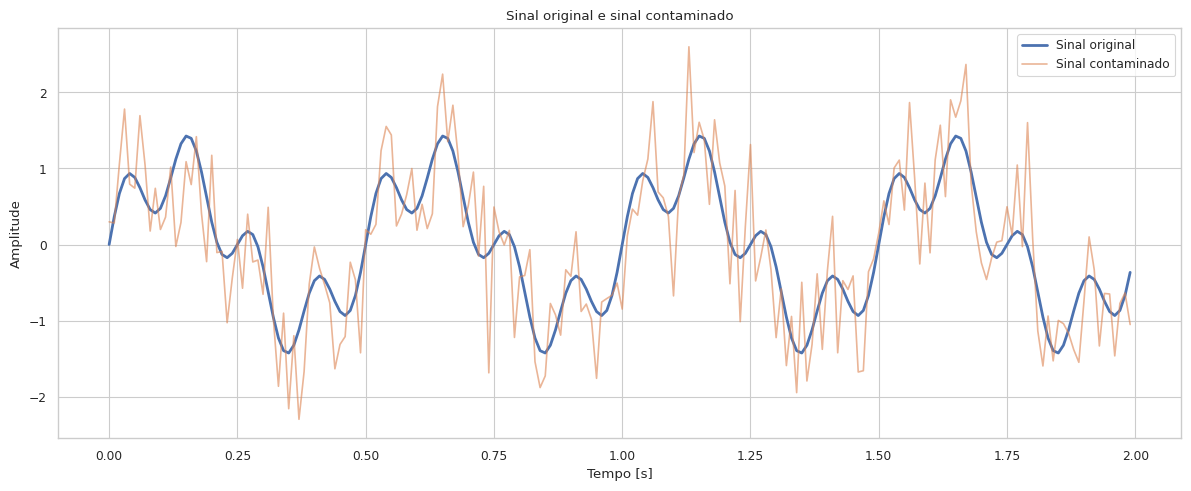

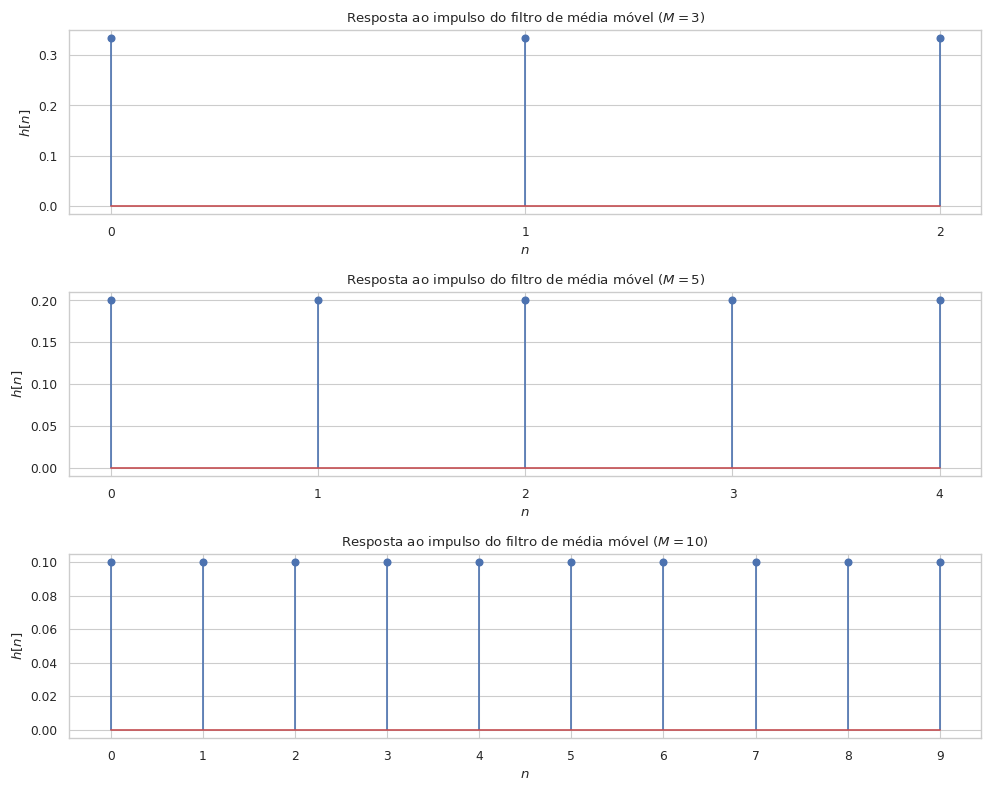

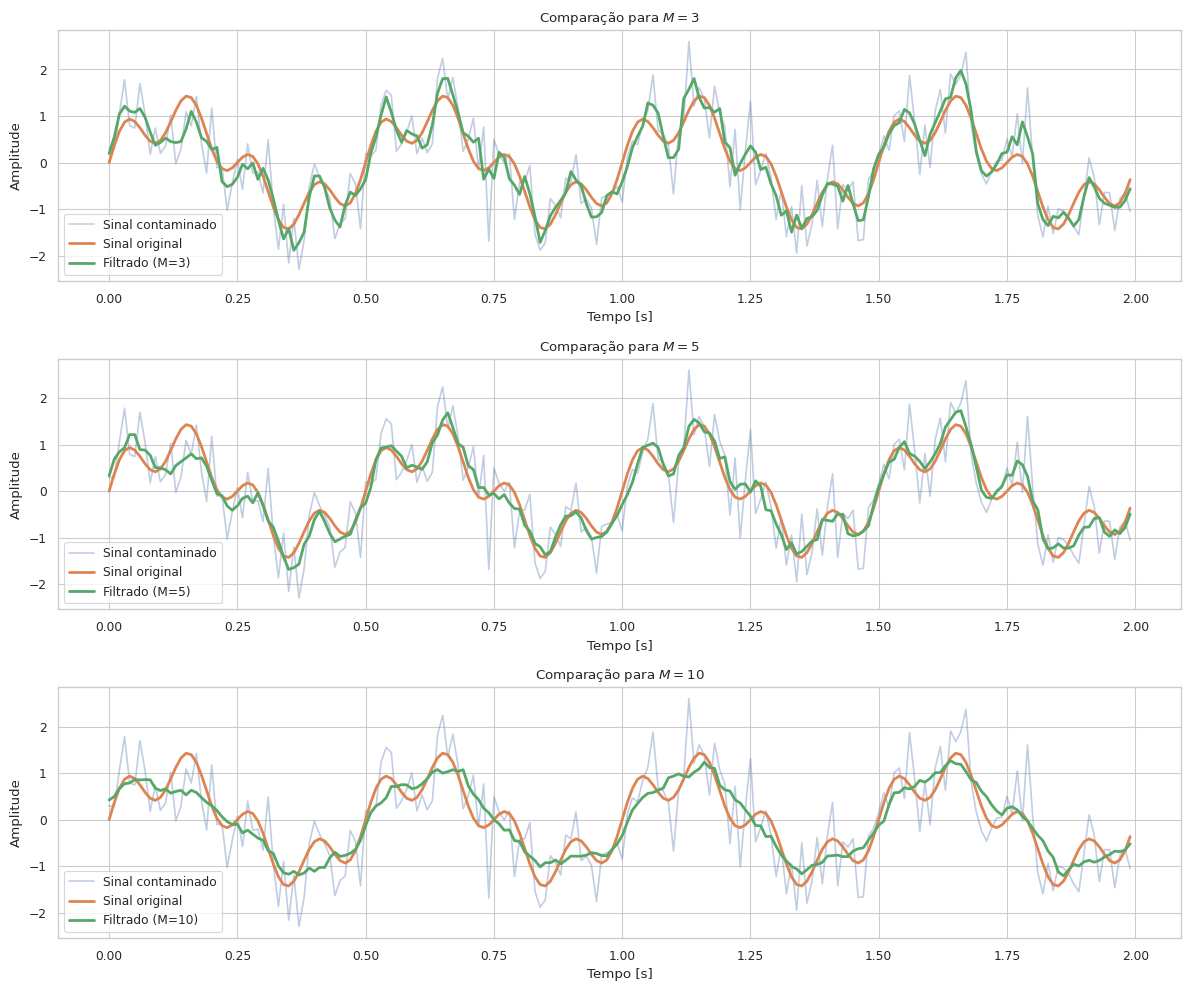

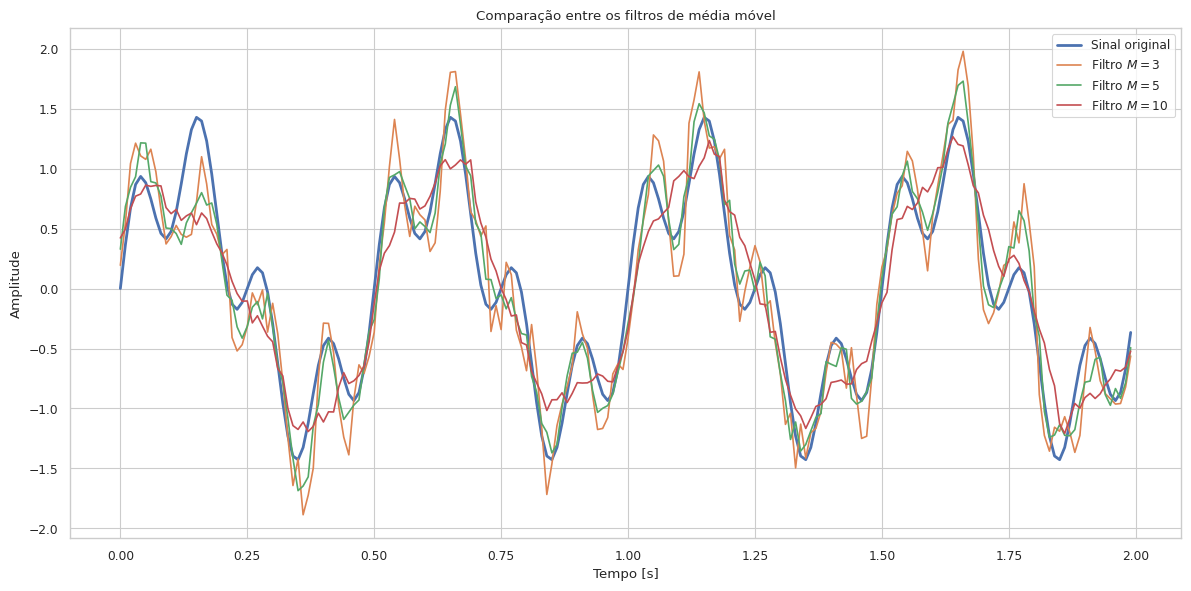

In [2]:
# ============================================================
# DEFINIÇÃO DOS PARÂMETROS
# ============================================================

fs = 100
Ts = 1 / fs

T = 2
t = np.arange(0, T, Ts)

f1 = 2
f2 = 8

# ============================================================
# SINAL ORIGINAL
# ============================================================

x = (
    np.sin(2 * np.pi * f1 * t)
    + 0.5 * np.sin(2 * np.pi * f2 * t)
)

# ============================================================
# GERAÇÃO DO RUÍDO
# ============================================================

ruido = 0.6 * np.random.randn(len(t))

x_contaminado = x + ruido

# ============================================================
# VALORES DE M PARA OS FILTROS
# ============================================================

M_values = [3, 5, 10]

# ============================================================
# APLICAÇÃO DOS FILTROS DE MÉDIA MÓVEL
# ============================================================

sinais_filtrados = {}

for M in M_values:

    h = np.ones(M) / M

    y = np.convolve(x_contaminado, h, mode="same")

    sinais_filtrados[M] = y

# ============================================================
# RESPOSTAS AO IMPULSO
# ============================================================

respostas_impulso = {}

for M in M_values:

    respostas_impulso[M] = np.ones(M) / M

# ============================================================
# RESULTADOS NUMÉRICOS
# ============================================================

resultados = []

for M in M_values:

    y = sinais_filtrados[M]

    erro = x - y

    erro_rms = np.sqrt(np.mean(erro**2))

    resultados.append({
        "M": M,
        "Erro RMS": erro_rms
    })

tabela_resultados = pd.DataFrame(resultados)

print("Resultados:")
print(tabela_resultados)

# ============================================================
# SINAL ORIGINAL E SINAL CONTAMINADO
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    t,
    x,
    label="Sinal original",
    linewidth=2
)

plt.plot(
    t,
    x_contaminado,
    label="Sinal contaminado",
    alpha=0.6
)

plt.title("Sinal original e sinal contaminado")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# RESPOSTAS AO IMPULSO
# ============================================================

fig, axes = plt.subplots(
    len(M_values),
    1,
    figsize=(10, 8)
)

for ax, M in zip(axes, M_values):

    h = respostas_impulso[M]
    n_h = np.arange(M)

    ax.stem(n_h, h)

    ax.set_title(
        rf"Resposta ao impulso do filtro de média móvel ($M={M}$)"
    )

    ax.set_xlabel(r"$n$")
    ax.set_ylabel(r"$h[n]$")
    ax.set_xticks(n_h)

plt.tight_layout()
plt.show()

# ============================================================
# COMPARAÇÃO DOS SINAIS FILTRADOS
# ============================================================

fig, axes = plt.subplots(
    len(M_values),
    1,
    figsize=(12, 10)
)

for ax, M in zip(axes, M_values):

    y = sinais_filtrados[M]

    ax.plot(
        t,
        x_contaminado,
        label="Sinal contaminado",
        alpha=0.35
    )

    ax.plot(
        t,
        x,
        label="Sinal original",
        linewidth=2
    )

    ax.plot(
        t,
        y,
        label=f"Filtrado (M={M})",
        linewidth=2
    )

    ax.set_title(
        rf"Comparação para $M={M}$"
    )

    ax.set_xlabel("Tempo [s]")
    ax.set_ylabel("Amplitude")
    ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# COMPARAÇÃO FINAL
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    t,
    x,
    label="Sinal original",
    linewidth=2
)

for M in M_values:

    plt.plot(
        t,
        sinais_filtrados[M],
        label=rf"Filtro $M={M}$"
    )

plt.title("Comparação entre os filtros de média móvel")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()